In [26]:
import nltk
import pandas as pd
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
import re
from nltk.stem import PorterStemmer, WordNetLemmatizer
import matplotlib.pyplot as plt

In [2]:
en_stopwords = stopwords.words('english')

In [3]:
review_df = pd.read_csv('tripadvisor_hotel_reviews.csv')

In [4]:
review_df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


## Lowercasing

In [5]:
review_df['review_lowercase'] = review_df.Review.str.lower()

In [6]:
review_df.head()

,Review,Rating,review_lowercase
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso..."


## Removing stop words

In [7]:
review_df['review_no_stopwords'] = review_df.review_lowercase.apply(lambda review: ' '.join([word for word in review.split() if word not in en_stopwords]))

In [8]:
review_df.head()

,Review,Rating,review_lowercase,review_no_stopwords
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso..."


## Removing Punctuations

In [9]:
review_df['review_no_stopwords_no_punct'] = review_df.review_no_stopwords.apply(lambda review: re.sub(r'\*', 'star', review))

In [10]:
review_df['review_no_stopwords_no_punct'] = review_df.review_no_stopwords_no_punct.apply(lambda review: re.sub(r'[^\w\s]', '', review))

In [11]:
review_df.head()

,Review,Rating,review_lowercase,review_no_stopwords,review_no_stopwords_no_punct
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...


## Tokenization

In [12]:
review_df['review_token'] = review_df.review_no_stopwords_no_punct.apply(lambda review: word_tokenize(review))

In [13]:
review_df.head()

,Review,Rating,review_lowercase,review_no_stopwords,review_no_stopwords_no_punct,review_token
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game..."


## Stemming

In [14]:
ps = PorterStemmer()

In [15]:
review_df['review_stem'] = review_df.review_token.apply(lambda token_list: [ps.stem(token) for token in token_list])

In [16]:
review_df.head()

,Review,Rating,review_lowercase,review_no_stopwords,review_no_stopwords_no_punct,review_token,review_stem
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco...","[nice, room, 4star, experi, hotel, monaco, sea..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."


## lemmatization

In [17]:
lemmatizer =  WordNetLemmatizer()

In [18]:
review_df['review_lemmatize'] = review_df.review_token.apply(lambda token_list: [lemmatizer.lemmatize(token) for token in token_list])

In [19]:
review_df.head()

,Review,Rating,review_lowercase,review_no_stopwords,review_no_stopwords_no_punct,review_token,review_stem,review_lemmatize
0,nice hotel expensive parking got good deal sta...,4,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,nice rooms not 4* experience hotel monaco seat...,nice rooms 4* experience hotel monaco seattle ...,nice rooms 4star experience hotel monaco seatt...,"[nice, rooms, 4star, experience, hotel, monaco...","[nice, room, 4star, experi, hotel, monaco, sea...","[nice, room, 4star, experience, hotel, monaco,..."
3,"unique, great stay, wonderful time hotel monac...",5,"unique, great stay, wonderful time hotel monac...","unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona...","[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,"great stay great stay, went seahawk game aweso...","great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."


## N-Grams 

In [20]:
all_words = review_df.review_lemmatize.sum()
print(all_words)

['nice', 'hotel', 'expensive', 'parking', 'got', 'good', 'deal', 'stay', 'hotel', 'anniversary', 'arrived', 'late', 'evening', 'took', 'advice', 'previous', 'review', 'valet', 'parking', 'check', 'quick', 'easy', 'little', 'disappointed', 'nonexistent', 'view', 'room', 'room', 'clean', 'nice', 'size', 'bed', 'comfortable', 'woke', 'stiff', 'neck', 'high', 'pillow', 'soundproof', 'like', 'heard', 'music', 'room', 'night', 'morning', 'loud', 'bang', 'door', 'opening', 'closing', 'hear', 'people', 'talking', 'hallway', 'maybe', 'noisy', 'neighbor', 'aveda', 'bath', 'product', 'nice', 'goldfish', 'stay', 'nice', 'touch', 'taken', 'advantage', 'staying', 'longer', 'location', 'great', 'walking', 'distance', 'shopping', 'overall', 'nice', 'experience', 'pay', '40', 'parking', 'night', 'ok', 'nothing', 'special', 'charge', 'diamond', 'member', 'hilton', 'decided', 'chain', 'shot', '20th', 'anniversary', 'seattle', 'start', 'booked', 'suite', 'paid', 'extra', 'website', 'description', 'not', '

In [21]:
unigram = pd.Series(nltk.ngrams(all_words, 1)).value_counts()

In [22]:
unigram

(hotel,)           292
(room,)            275
(great,)           126
(stay,)             95
(staff,)            90
                  ... 
(175,)               1
(smackagainst,)      1
(2x,)                1
(80,)                1
(connected,)         1
Name: count, Length: 2589, dtype: int64

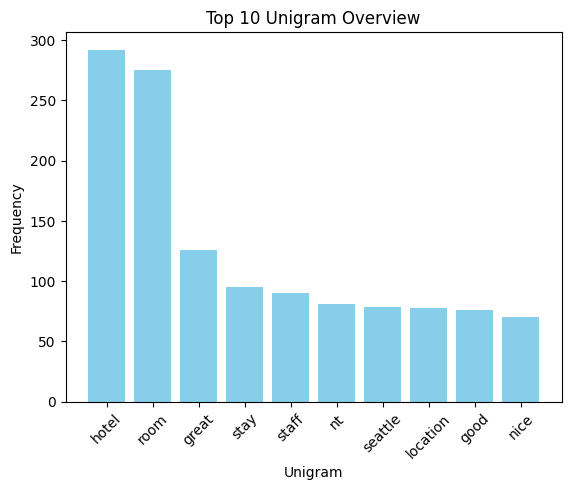

In [36]:
top_10_unigrams = unigram.head(10)
words = [word[0] for word in top_10_unigrams.index]

plt.bar(words, top_10_unigrams.values, color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Unigram Overview')
plt.xlabel('Unigram')
plt.ylabel('Frequency')
plt.show()

In [23]:
bigram = pd.Series(nltk.ngrams(all_words, 2)).value_counts()

In [24]:
bigram

(great, location)           24
(space, needle)             21
(hotel, monaco)             16
(staff, friendly)           13
(great, view)               12
                            ..
(hotel, dissapointment)      1
(unfortunately, warwick)     1
(agency, unfortunately)      1
(travel, agency)             1
(food, raffle)               1
Name: count, Length: 8183, dtype: int64

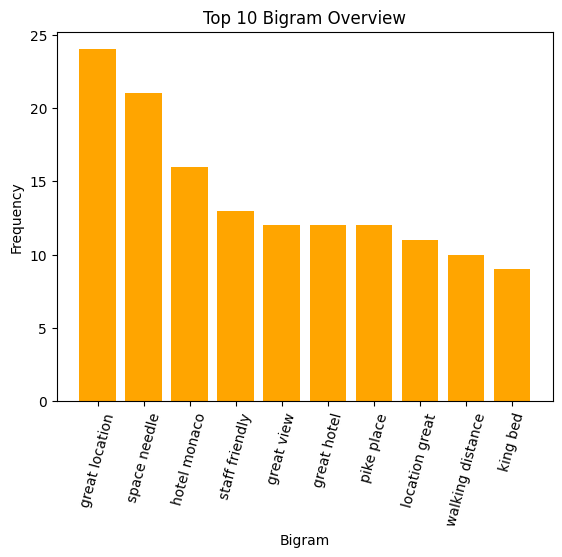

In [43]:
top_10_bigrams = bigram.head(10)
bigram_words = [' '.join(word) for word in top_10_bigrams.index]

plt.bar(bigram_words, top_10_bigrams.values, color='orange')
plt.xticks(rotation=75)
plt.title('Top 10 Bigram Overview')
plt.xlabel('Bigram')
plt.ylabel('Frequency')
plt.show()

In [25]:
trigram = pd.Series(nltk.ngrams(all_words, 3)).value_counts()
trigram

(pike, place, market)         8
(hotel, great, location)      5
(staff, friendly, helpful)    5
(view, space, needle)         5
(room, king, bed)             4
                             ..
(free, travel, central)       1
(cheap, free, travel)         1
(bus, cheap, free)            1
(seattle, bus, cheap)         1
(hotel, right, street)        1
Name: count, Length: 9173, dtype: int64

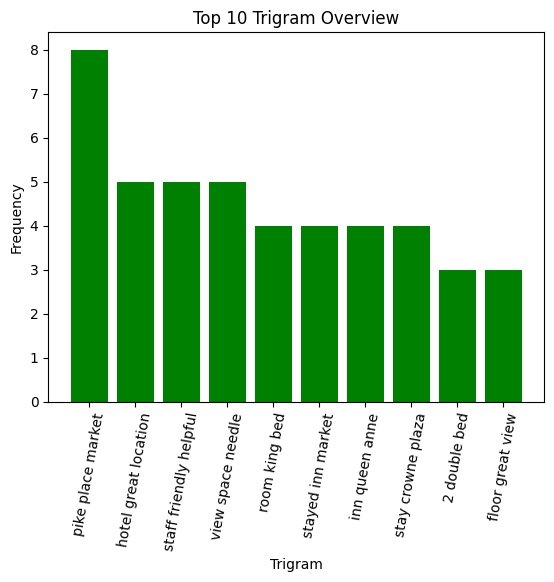

In [47]:
top_10_trigrams = trigram.head(10)
trigram_words = [' '.join(word) for word in top_10_trigrams.index]

plt.bar(trigram_words, top_10_trigrams.values, color='green')
plt.xticks(rotation=80)
plt.title('Top 10 Trigram Overview')
plt.xlabel('Trigram')
plt.ylabel('Frequency')
plt.show()